# **This file is for training the Ensemble and creating the weight files**

# **Pre-requisites**

In [ ]:
import numpy as np
import pandas as pd
import random
import os
import cv2
import PIL
from IPython.display import Image
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from collections import Counter
import tensorflow as tf
import itertools
from pathlib import Path
import keras
import imagesize
from keras import backend as K
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.applications.inception_v3 import InceptionV3
from tensorflow.keras.applications.resnet50 import ResNet50
from tensorflow.keras.applications.vgg16 import VGG16
from keras import Model, layers
from keras.models import Sequential, load_model
from tensorflow.keras.optimizers import Adam, SGD
import torch
from keras.layers import GlobalMaxPooling2D, GlobalAveragePooling2D, Dropout, Dense, Input, Conv2D, MaxPooling2D, Flatten,MaxPooling3D

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

PROJECT_ROOT = "/content/drive/MyDrive/Capstone"

In [40]:
def get_default_device():
    if torch.cuda.is_available():
        return torch.device('cuda')
    else:
        return torch.device('cpu')

device = get_default_device()
device

device(type='cuda')

# **One time execution**

In [41]:
!pip install -q split-folders

In [42]:
import splitfolders

In [ ]:

def split():
    data_dir = os.path.join(f'{PROJECT_ROOT}/Cyclone-Data/data_categorised')
    print("No of images in each class of data directory")
    for dir, subdir, files in os.walk(data_dir):
        print(dir,':', str(len(files)))

    splitfolders.ratio(f"{PROJECT_ROOT}/Cyclone-Data/data_categorised",
                       output = f"{PROJECT_ROOT}/Cyclone-Data/multiclass_data_folders/",
                       seed = 6,
                       ratio = (0.8, 0.2),
                       group_prefix = None,
                       move = False)

if os.path.exists(f"{PROJECT_ROOT}/Cyclone-Data/multiclass_data_folders/train"):
    print("Files already present in splitted format")
else:
    split()
    print("Files are splitted in the ratio 0.8, 0.2")


In [ ]:
dir_path = '/content/drive/MyDrive/multiclass_augmented/'
count = 0
# Iterate directory
for path in os.listdir(dir_path):
    # check if current path is a file
    if os.path.isfile(os.path.join(dir_path, path)):
        count += 1
print('Augmented File count:', count)

# **Utility Function**

In [77]:
def plot_accuracy_from_history(history, isinception = False):
    color = sns.color_palette()
    if(isinception == False):
        acc = history.history['acc']
        val_acc = history.history['val_acc']
    else:
        acc = history.history['acc']
        val_acc = history.history['val_acc']


    epochs = range(len(acc))

    sns.lineplot(x=epochs, y=acc, label='Training Accuracy')
    sns.lineplot(x=epochs, y=val_acc,label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.legend()
    plt.figure()
    plt.show()

In [78]:
def plot_loss_from_history(history):
    color = sns.color_palette()
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    epochs = range(len(loss))

    sns.lineplot(x=epochs, y=loss,label='Training Loss')
    sns.lineplot(x=epochs, y=val_loss, label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    plt.figure()
    plt.show()

In [ ]:
def do_history_stuff(history, history_file_name, isinception=False):
    plot_accuracy_from_history(history, isinception)
    plot_loss_from_history(history)

In [ ]:
def show_few_images(number_of_examples = 2, predict_using_model = None):
    figure1, ax1 = plt.subplots(number_of_examples,len(os.listdir(train_folders)), figsize=(20,4*number_of_examples))
    ax1 = ax1.reshape(-1)
    axoff_fun = np.vectorize(lambda ax:ax.axis('off'))
    axoff_fun(ax1)
    axs = 0
    for i, folder in enumerate(os.listdir(train_folders)):
        image_ids = os.listdir(os.path.join(train_folders,folder))
        for j in [random.randrange(0, len(image_ids)) for i in range(0,number_of_examples)]:
            display = plt.imread(os.path.join(train_folders,folder,image_ids[j]))
            plt.axis('off')
            ax1[axs].imshow(display)
            title = 'True:'+folder
            if(predict_using_model):
                predicted_classname = inv_map_classes[np.argmax(inception_best_model.predict(np.array([display])))]
                title = title+'\nPredict :'+predicted_classname
            ax1[axs].set_title(title)
            axs=axs+1

In [ ]:
def clf_report(true_value, model_pred):
    classes = validation_generator.class_indices.keys()
    TP_count = [true_value[i] == model_pred[i] for i in range(len(true_value))]
    model_accuracy = np.sum(TP_count)/len(TP_count)
    print('Model Accuracy', model_accuracy)
    plt.figure(figsize=(7,7))
    cm = confusion_matrix(true_value,model_pred)
    plt.imshow(cm,interpolation='nearest',cmap=plt.cm.viridis)
    plt.title('Confusion Matrix')
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)
    thresh = cm.max()*0.8
    for i,j in itertools.product(range(cm.shape[0]),range(cm.shape[1])):
        plt.text(j,i,cm[i,j],
                horizontalalignment="center",
                color="black" if cm[i,j] > thresh else "white")
        pass

    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    pass
    print(classification_report(true_value, model_pred, target_names = list(classes)))

# **Data Preparation**

In [ ]:
train_folders = f'{PROJECT_ROOT}/Cyclone-Data/multiclass_data_folders/train'
val_folders = f'{PROJECT_ROOT}/Cyclone-Data/multiclass_data_folders/val'

In [ ]:
sum = 0
data_dir = os.path.join(f"{PROJECT_ROOT}/Cyclone-Data/multiclass_data_folders")
print("No of images in each class of the directory")
for dir, subdir, files in os.walk(data_dir):
    if len(files) == 0:
        continue
    else:
        print(dir, ':', str(len(files)))
        sum += len(files)
print("Total no of images:", sum)

In [ ]:
#checking the resolution of a random image to find desired target size
root = data_dir + "/train/VSCS(70-90)/"

imgs = [img.name for img in Path(root).iterdir() if img.suffix == ".jpg"]
img_meta = {}
for f in imgs: img_meta[str(f)] = imagesize.get(root+f)

# Convert it to Dataframe and compute aspect ratio
img_meta_df = pd.DataFrame.from_dict([img_meta]).T.reset_index().set_axis(['FileName', 'Size'], axis = 'columns')
img_meta_df[["Width", "Height"]] = pd.DataFrame(img_meta_df["Size"].tolist(), index = img_meta_df.index)
img_meta_df["Aspect Ratio"] = round(img_meta_df["Width"] / img_meta_df["Height"], 2)

print(f'Total number of images in the dataset: {len(img_meta_df)}')
img_meta_df.head()

In [ ]:
#check if any image file height is more than 350
temp_df = img_meta_df[img_meta_df['Height'] > 350]
temp_df.head()

In [ ]:
# Visualize Image Resolutions
fig = plt.figure(figsize = (5, 5))
ax = fig.add_subplot(111)
points = ax.scatter(img_meta_df.Width, img_meta_df.Height, color = 'blue', alpha = 0.5, s = img_meta_df["Aspect Ratio"]*100, picker=True)
ax.set_title("Image Resolution")
ax.set_xlabel("Width", size = 14)
ax.set_ylabel("Height", size = 14);

We are rescaling by 1.0/255 to normalize the rgb values if they are in range 0-255 the values are too high for good model performance.
We are only normalising to make the prediction, the other parameters were used for agumentation and train weights

In [58]:
train_datagen = ImageDataGenerator(rescale = 1.0/255., rotation_range = 10)
train_generator = train_datagen.flow_from_directory(train_folders, batch_size = 2, class_mode = 'categorical', target_size = (310, 310))

validation_datagen = ImageDataGenerator(rescale = 1.0/255.)
validation_generator = validation_datagen.flow_from_directory(val_folders, batch_size = 1, class_mode = 'categorical', target_size = (310, 310), shuffle = False)

Found 1473 images belonging to 5 classes.
Found 371 images belonging to 5 classes.


In [ ]:
inv_map_classes = {v: k for k, v in validation_generator.class_indices.items()}
print(validation_generator.class_indices)
print(inv_map_classes)

In [ ]:
show_few_images(2)

In [ ]:
plt.figure(figsize = (10, 12))
plt.tight_layout()
classes_dict = {
    0 : 'D(20-25)',
    1 : 'DD(30-35)',
    2 : 'CS(40-50)',
    3 : 'SevereCS(55-65)',
    4 : 'VSCS(70+)'
}
for i,folder in enumerate(os.listdir(train_folders)):
    path = os.path.join(train_folders,folder)
    img_ls = os.listdir(path)
    for j,im_name in enumerate(img_ls[:4]):
        plt.subplot(5, 4, 4 * i+j+1)
        img_path = os.path.join(path, im_name)
        img = PIL.Image.open(img_path)
        plt.imshow(img, cmap = 'gray')
        plt.axis("off")
        plt.title(classes_dict[int(i)])
        plt.savefig('xyz')

In [62]:
vgg_epoch = 30
resnet_epoch = 15
inception_epoch = 20

# **VGG-16 Model**

In [63]:
tf.keras.backend.clear_session()

Input here is 4D array (batchsize, height, width, channels) - we have already created the train_generator with batch size 2. Images of size each 150x150 with 3 color channels will be input into this layer

In [64]:
vgg16_model = VGG16(pooling = 'avg', weights = 'imagenet', include_top = False, input_shape = (310, 310, 3))
for layers in vgg16_model.layers:
  layers.trainable = False
last_output = vgg16_model.layers[-1].output
vgg_x = Flatten()(last_output)
vgg_x = Dense(128, activation = 'relu')(vgg_x)
vgg_x = Dense(5, activation = 'softmax')(vgg_x)
vgg16_final_model = Model(vgg16_model.input, vgg_x)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [70]:
vgg16_final_model.compile(loss = 'categorical_crossentropy', optimizer = Adam(learning_rate = 0.0001), metrics = ['acc'])

In [71]:
early_stopping = tf.keras.callbacks.EarlyStopping(monitor = 'val_loss', patience = 5, verbose = 1)

In [ ]:
vgg16_filepath = 'vgg_16_'+'-saved-model-{epoch:02d}-acc-{val_acc:.2f}.keras'
checkpoint = tf.keras.callbacks.ModelCheckpoint(vgg16_filepath, monitor='val_acc', verbose=1, save_best_only=True, mode='max')

history = vgg16_final_model.fit(train_generator, epochs = vgg_epoch, validation_data = validation_generator, callbacks = [checkpoint, early_stopping], verbose = 1)

In [ ]:
vgg16_final_model.save(f'{PROJECT_ROOT}/Model_Weights/multiclass_vgg_model.keras')

In [ ]:
do_history_stuff(history, 'vgg16_model')

In [ ]:
vgg_best_model = vgg16_final_model
true_value = []
vgg_pred = []
for folder in os.listdir(val_folders):
    val_image_ids = os.listdir(os.path.join(val_folders,folder))
    for image_id in val_image_ids[:int(len(val_image_ids))]:
        path = os.path.join(val_folders, folder, image_id)
        true_value.append(validation_generator.class_indices[folder])
        img = cv2.resize(cv2.imread(path),(310, 310))
        img_normalized = img/255
        vgg16_image_prediction = np.argmax(vgg_best_model.predict(np.array([img_normalized])))
        vgg_pred.append(vgg16_image_prediction)

In [81]:
def clf_report(true_value, model_pred):
    classes = validation_generator.class_indices.keys()
    TP_count = [true_value[i] == model_pred[i] for i in range(len(true_value))]
    model_accuracy = np.sum(TP_count)/len(TP_count)
    print('Model Accuracy', model_accuracy)
    plt.figure(figsize=(7,7))
    cm = confusion_matrix(true_value,model_pred)
    plt.imshow(cm,interpolation='nearest',cmap=plt.cm.viridis)
    plt.title('Confusion Matrix')
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)
    thresh = cm.max()*0.8
    for i,j in itertools.product(range(cm.shape[0]),range(cm.shape[1])):
        plt.text(j,i,cm[i,j],horizontalalignment="center", color="black" if cm[i,j] > thresh else "white")
        pass
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    pass
    print(classification_report(true_value, model_pred, target_names = list(classes)))

In [ ]:
clf_report(true_value, vgg_pred)

# **ResNet-50 Model**

In [83]:
tf.keras.backend.clear_session()

In [84]:
ResNet50_model = ResNet50(weights='imagenet', include_top = False, input_shape = (310,310,3), classes=5)
for layers in ResNet50_model.layers:
    layers.trainable = True

# resnet50_x = Conv2D(64, (3, 3), activation='relu')(ResNet50_model.output)
# resnet50_x = MaxPooling2D(pool_size=(3, 3))(resnet50_x)
resnet50_x = Flatten()(ResNet50_model.output)
resnet50_x = Dense(256,activation='relu')(resnet50_x)
resnet50_x = Dense(5,activation='softmax')(resnet50_x)
resnet50_x_final_model = Model(inputs = ResNet50_model.input, outputs = resnet50_x)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


In [85]:
resnet50_x_final_model.compile(loss = 'categorical_crossentropy', optimizer = Adam(learning_rate = 0.0001), metrics = ['acc'])

In [86]:
early_stopping = tf.keras.callbacks.EarlyStopping(monitor = 'loss', patience = 5)
reduce_lr = ReduceLROnPlateau(monitor = 'val_loss', factor = 0.05, patience = 5, min_lr = 0.00002)

In [ ]:
history = resnet50_x_final_model.fit(train_generator, epochs = resnet_epoch, validation_data = validation_generator,
                                              callbacks= [early_stopping,reduce_lr], verbose=1)

In [ ]:
resnet50_x_final_model.save(f'{PROJECT_ROOT}/Model_Weights/multiclass_resnet_model.keras')

In [ ]:
do_history_stuff(history, 'resnet50_model')

In [ ]:
resnet_best_model = resnet50_x_final_model
resnet_pred = []
true_value = []
for folder in os.listdir(val_folders):
    val_image_ids = os.listdir(os.path.join(val_folders,folder))
    for image_id in val_image_ids[:int(len(val_image_ids))]:
        path = os.path.join(val_folders,folder,image_id)
        true_value.append(validation_generator.class_indices[folder])
        img = cv2.resize(cv2.imread(path),(310,310))
        img_normalized = img/255
        resnet_50_image_prediction = np.argmax(resnet_best_model.predict(np.array([img_normalized])))
        resnet_pred.append(resnet_50_image_prediction)

In [91]:
def clf_report(true_value, model_pred):
    classes = validation_generator.class_indices.keys()
    TP_count = [true_value[i] == model_pred[i] for i in range(len(true_value))]
    model_accuracy = np.sum(TP_count)/len(TP_count)
    print('Model Accuracy', model_accuracy)
    plt.figure(figsize=(7,7))
    cm = confusion_matrix(true_value,model_pred)
    plt.imshow(cm,interpolation='nearest',cmap=plt.cm.viridis)
    plt.title('Confusion Matrix')
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)
    thresh = cm.max()*0.8
    for i,j in itertools.product(range(cm.shape[0]),range(cm.shape[1])):
        plt.text(j,i,cm[i,j],
                horizontalalignment="center",
                color="black" if cm[i,j] > thresh else "white")
        pass

    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    pass

    print(classification_report(true_value, model_pred, target_names = list(classes)))

In [ ]:
clf_report(true_value, resnet_pred)

# **Inceptionv3 Model**

In [94]:
tf.keras.backend.clear_session()

In [95]:
InceptionV3_model = InceptionV3(input_shape = (310, 310, 3), weights = 'imagenet', include_top = False)
for layer in InceptionV3_model.layers[:249]:
   layer.trainable = False
for layer in InceptionV3_model.layers[249:]:
   layer.trainable = True

InceptionV3_last_output = InceptionV3_model.output
InceptionV3_maxpooled_output = Flatten()(InceptionV3_last_output)
InceptionV3_x = Dense(1024, activation = 'relu')(InceptionV3_maxpooled_output)
InceptionV3_x = Dropout(0.5)(InceptionV3_x)
InceptionV3_x = Dense(5, activation = 'softmax')(InceptionV3_x)
InceptionV3_x_final_model = Model(inputs = InceptionV3_model.input, outputs = InceptionV3_x)

In [96]:
InceptionV3_x_final_model.compile(optimizer = Adam(learning_rate = 0.0001), loss = 'categorical_crossentropy', metrics = ['acc'])

In [97]:
early_stopping = tf.keras.callbacks.EarlyStopping(monitor = 'loss', patience = 5)

In [ ]:
history = InceptionV3_x_final_model.fit(train_generator, epochs = inception_epoch, validation_data = validation_generator, callbacks = [early_stopping], verbose=1)

In [ ]:
InceptionV3_x_final_model.save(f'{PROJECT_ROOT}/Model_Weights/multiclass_inception_model.keras')

In [ ]:
do_history_stuff(history, 'inceptionv3_model', True)

In [ ]:
inception_best_model = InceptionV3_x_final_model
true_value = []
inception_pred = []
for folder in os.listdir(val_folders):
    test_image_ids = os.listdir(os.path.join(val_folders,folder))
    for image_id in test_image_ids[:int(len(test_image_ids))]:
        path = os.path.join(val_folders,folder,image_id)
        true_value.append(validation_generator.class_indices[folder])
        img = cv2.resize(cv2.imread(path),(310,310))
        img_normalized = img/255
        inception_image_prediction = np.argmax(inception_best_model.predict(np.array([img_normalized])))
        inception_pred.append(inception_image_prediction)

In [102]:
def clf_report(true_value, model_pred):
    classes = validation_generator.class_indices.keys()
    TP_count = [true_value[i] == model_pred[i] for i in range(len(true_value))]
    model_accuracy = np.sum(TP_count)/len(TP_count)
    print('Model Accuracy', model_accuracy)
    plt.figure(figsize=(7,7))
    cm = confusion_matrix(true_value,model_pred)
    plt.imshow(cm,interpolation='nearest',cmap=plt.cm.viridis)
    plt.title('Confusion Matrix')
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)
    thresh = cm.max()*0.8
    for i,j in itertools.product(range(cm.shape[0]),range(cm.shape[1])):
        plt.text(j,i,cm[i,j],
                horizontalalignment="center",
                color="black" if cm[i,j] > thresh else "white")
        pass

    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    pass

    print(classification_report(true_value, model_pred, target_names = list(classes)))

In [ ]:
clf_report(true_value, inception_pred)

# **Visualise Feature Maps**

In [ ]:
model = load_model(f'{PROJECT_ROOT}/Model_Weights/multiclass_inception_model.keras')

In [ ]:
model.layers

In [115]:
# summarize feature map shapes
for i in range(len(model.layers)):
    layer = model.layers[i]
    if 'conv' not in layer.name:
        continue
    print(i, layer.name, layer.output.shape)

In [116]:
import glob, random
#file_path_type = ["/content/drive/MyDrive/train/VSCS(70-90)/*.jpg"]
#images = glob.glob(random.choice(file_path_type))
#img_path = random.choice(images)

In [ ]:
img_path = f'{PROJECT_ROOT}/Cyclone-Data/multiclass_data_folders/val/CS(40-50)/20001127.12-45.jpg'

In [ ]:
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.models import Model
from numpy import expand_dims

# redefine model to output right after the first hidden layer
model = Model(inputs = model.inputs, outputs = model.layers[1].output)
img = load_img(img_path, target_size = (310, 310))

# convert the image to an array
img = img_to_array(img)
# expand dimensions so that it represents a single 'sample'
img = expand_dims(img, axis = 0)
# prepare the image (e.g. scale pixel values for the vgg)
img = preprocess_input(img)
# get feature map for first hidden layer
feature_maps = model.predict(img)
# plot all 32 maps in an 8x8 squares
rows = 8
columns = 4
ix = 1
plt.figure(figsize=(10, 20))
for _ in range(rows):
    for _ in range(columns):
        # specify subplot and turn of axis
        ax = plt.subplot(rows, columns, ix)
        ax.set_xticks([])
        ax.set_yticks([])
        plt.imshow(feature_maps[0, :, :, ix-1], cmap = 'pink')
        ix += 1
plt.tight_layout()
plt.savefig("Feature Maps" + ".jpg", transparent = True, bbox_inches = 'tight')
plt.show()

# **Ensemble Model**

In [ ]:
vgg_best_model = load_model(f'{PROJECT_ROOT}/Model_Weights/multiclass_vgg_model.keras')
resnet_best_model = load_model(f'{PROJECT_ROOT}/Model_Weights/multiclass_resnet_model.keras')
inception_best_model = load_model(f'{PROJECT_ROOT}/Model_Weights/multiclass_inception_model.keras')

In [ ]:
def mode(my_list):
    ct = Counter(my_list)
    max_value = max(ct.values())
    return ([key for key, value in ct.items() if value == max_value])

true_value = []
combined_model_pred = []
vgg_pred = []
resnet_pred = []
inception_pred = []
for folder in os.listdir(val_folders):

    test_image_ids = os.listdir(os.path.join(val_folders,folder))

    for image_id in test_image_ids[:int(len(test_image_ids))]:

        path = os.path.join(val_folders,folder,image_id)

        true_value.append(validation_generator.class_indices[folder])
        img = cv2.resize(cv2.imread(path),(310,310))
        img_normalized = img/255

        #vgg16
        vgg16_image_prediction = np.argmax(vgg_best_model.predict(np.array([img_normalized])))
        vgg_pred.append(vgg16_image_prediction)

        #resnet50
        resnet_50_image_prediction = np.argmax(resnet_best_model.predict(np.array([img_normalized])))
        resnet_pred.append(resnet_50_image_prediction)

        #Inception
        inception_image_prediction = np.argmax(inception_best_model.predict(np.array([img_normalized])))
        inception_pred.append(inception_image_prediction)

        image_prediction = mode([resnet_50_image_prediction, inception_image_prediction, vgg16_image_prediction])
        combined_model_pred.append(image_prediction)

In [128]:
def clf_report(true_value, model_pred):
    classes = validation_generator.class_indices.keys()
    TP_count = [true_value[i] == model_pred[i] for i in range(len(true_value))]
    model_accuracy = np.sum(TP_count)/len(TP_count)
    print('Model Accuracy', model_accuracy)

    plt.figure(figsize = (7, 7))
    cm = confusion_matrix(true_value,model_pred)
    plt.imshow(cm,interpolation='nearest',cmap=plt.cm.viridis)
    plt.title('Confusion Matrix')
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)
    thresh = cm.max()*0.8
    for i,j in itertools.product(range(cm.shape[0]),range(cm.shape[1])):
        plt.text(j,i,cm[i,j],
                horizontalalignment="center",
                color="black" if cm[i,j] > thresh else "white")
        pass

    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    pass

    print(classification_report(true_value, model_pred, target_names = list(classes)))

Model Accuracy 0.6253369272237197
                 precision    recall  f1-score   support

      CS(40-50)       0.61      0.50      0.55        80
       D(20-25)       0.75      0.56      0.65        71
      DD(30-35)       0.61      0.80      0.69       107
SevereCS(55-65)       0.51      0.44      0.47        52
    VSCS(70-90)       0.66      0.70      0.68        61

       accuracy                           0.63       371
      macro avg       0.63      0.60      0.61       371
   weighted avg       0.63      0.63      0.62       371



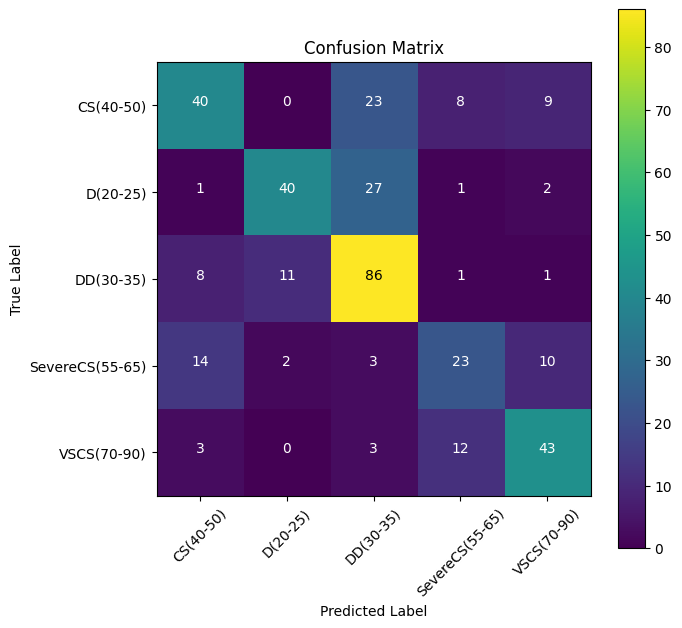

In [129]:
combined_model_pred = [c[0] for c in combined_model_pred]
clf_report(true_value, combined_model_pred)